## Combinatorial Subspace Subtraction

[Attention as Binding: A Vector-Symbolic Perspective on Transformer Reasoning](https://openreview.net/forum?id=wQDFkHOAZc)


[Adversarial Concept Search: Predicting Compositional Errors From Feature Geometry](https://arxiv.org/html/2606.13934v1)
[]()

In [ ]:
!pip install seaborn plotly transformer_lens
!pip uninstall -y torchaudio

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json
import numpy as np
import torch
from google.colab import drive
from huggingface_hub import login
from transformer_lens import HookedTransformer

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!ls drive/MyDrive/Projects/PRISM/data

CombSub_dataset.json		   GrammarDiss_dataset_variantB.json
GrammarDiss_contexts.json	   GrammarDiss_dataset_variantC.json
GrammarDiss_dataset_variantA.json  GrammarDiss_rules.json


In [ ]:
# HF login for Llamas
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained_no_processing(
    "meta-llama/Llama-3.2-1B-Instruct",
    device=device,
    torch_dtype=torch.float16,
)

n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer


In [ ]:
FILE_PATH = "/content/drive/MyDrive/Projects/PRISM/data/CombSub_dataset.json"

In [ ]:
with open(FILE_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

In [ ]:
trainset = dataset["train"]
rule_types = [i["rule_type"] for i in trainset]
full_rules = [i["assembled_full_rule"] for i in trainset]
domains_a = [i["assembled_domain_a"] for i in trainset]
domains_b = [i["assembled_domain_b"] for i in trainset]
contexts = [i["context"] for i in trainset]

In [ ]:
len(rule_types) == len(trainset) == len(full_rules)

True

In [ ]:
def get_last_token_acts(prompts):
    acts = np.zeros((len(prompts), n_layers, d_model), dtype=np.float32)
    for idx, p in enumerate(prompts):
        with torch.no_grad():
            _, cache = model.run_with_cache(p, stop_at_layer=n_layers)
        for l in range(n_layers):
            acts[idx, l, :] = cache[f"blocks.{l}.hook_resid_post"][0, -1, :].cpu().numpy()
    return acts

In [ ]:
act_full_rules  = get_last_token_acts(full_rules)
act_domainsA = get_last_token_acts(domains_a)
act_domainsB = get_last_token_acts(domains_b)
act_contexts  = get_last_token_acts(contexts)

In [ ]:
act_full_rules.shape, act_domainsA.shape, act_domainsB.shape, act_contexts.shape

((100, 16, 2048), (100, 16, 2048), (100, 16, 2048), (100, 16, 2048))

#### Extracting CSS vectors

In [ ]:
def extract_binding_vectors(act_R, act_D1, act_D2, act_C):
    """
    Computes the interaction term/binding vectors.
    """
    # Formula: b = R - [D1 + D2 - C]
    binding_vectors = act_R - (act_D1 + act_D2 - act_C)
    return binding_vectors # act_R=Weather is nice. Reply in 5 words in French; act_D1=weather is nice,reply in 5 words; act_D2=FRench;

In [ ]:
bind_vectors = extract_binding_vectors(act_full_rules, act_domainsA, act_domainsB, act_contexts)

In [ ]:
bind_vectors.shape

(100, 16, 2048)

In [ ]:
!pip install plotly scikit-learn

In [ ]:
import plotly.io as pio
from sklearn.decomposition import PCA
import plotly.express as px
from google.colab import files

In [ ]:
def visualize_binding_space_via_download(binding_vectors, rule_labels, layer_idx):
  """Runs PCA and visualises the binding vectors in 3D."""
  layer_data = binding_vectors[:, layer_idx, :]

  pca = PCA(n_components=3)
  pca_results = pca.fit_transform(layer_data)
  fig = px.scatter_3d(
        x=pca_results[:, 0],
        y=pca_results[:, 1],
        z=pca_results[:, 2],
        color=rule_labels,
        labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
        title=f"3D PCA Manifold of Universal Binding Vectors (Layer {layer_idx})",
        opacity=0.8,
        color_discrete_sequence=px.colors.qualitative.Bold
    )
  fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=40),
        scene=dict(
            xaxis=dict(backgroundcolor="rgba(0,0,0,0)"),
            yaxis=dict(backgroundcolor="rgba(0,0,0,0)"),
            zaxis=dict(backgroundcolor="rgba(0,0,0,0)")
        )
    )
  # make sure it opens in a browser, not in the cell
  filename = f"binding_space_3d_layer{layer_idx}.html"
  fig.write_html(filename)
  files.download(filename)

In [ ]:
visualize_binding_space_via_download(bind_vectors, rule_types, 15)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_binding_space_via_download(bind_vectors, rule_types, 4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_binding_space_via_download(bind_vectors, rule_types, 10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_binding_space_via_download(bind_vectors, rule_types, 13)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Checking if the binding vectors are pure noise

In [ ]:
import numpy as no
from matplotlib import pyplot as plt

In [ ]:
bind_vectors.shape

(100, 16, 2048)

In [ ]:
def plot_signal_to_noise_ratio(bin_vectors, act_R, act_D1, act_D2, act_C, plot_snr=True):
    """
    Computes Signal2Noise Ratio (SNR) for the binding vectors.
    """
    n_samples, n_layers, d_model = bin_vectors.shape
    snr_timeline = []
    true_timeline = []
    shuffled_timeline = []

    bin_vectors = act_R - (act_D1 + act_D2 - act_C) # res_stream = res_stream - bin_vectors; projecting it out
    # TODO google about subtraction vs projecting out
    noise_matrix = act_D1 + act_D2 - act_C

    # shuffling the the rows
    shuffled_indices = np.random.permutation(n_samples)
    b_shuffled_matrix = act_R - noise_matrix[shuffled_indices, :, :]

    # layer by layer SNR
    for l in range(n_layers):

        layer_true = bin_vectors[:, l, :]
        layer_shuffled = b_shuffled_matrix[:, l, :]

        # L2norms
        norms_true = np.linalg.norm(layer_true, axis=1)
        norms_shuffled = np.linalg.norm(layer_shuffled, axis=1)

        # taking means
        mean_signal = np.mean(norms_true)
        mean_noise = np.mean(norms_shuffled)

        layer_snr = mean_signal / mean_noise if mean_noise > 0 else 0
        snr_timeline.append(layer_snr)
        true_timeline.append(mean_signal)
        shuffled_timeline.append(mean_noise)

    if plot_snr:
        plt.figure(figsize=(10, 5))
        plt.plot(range(n_layers), snr_timeline, marker='o', color='blue', linewidth=1.5, label="SNR")

        # Threshold references
        plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label="Noise Floor (SNR = 1.0)")
        plt.axhline(y=1.25, color='orange', linestyle=':', alpha=0.7, label="Acceptable Signal Threshold (SNR = 1.5)")

        plt.title("SNR of Binding Vectors Across Layers", fontsize=12, fontweight='bold', pad=15)
        plt.xlabel("Layer Index", fontsize=10)
        plt.ylabel(f"SNR Ratio", fontsize=10)
        plt.xticks(range(n_layers))
        plt.grid(True, alpha=0.2)
        plt.legend()
        plt.show()

    return snr_timeline, true_timeline, shuffled_timeline

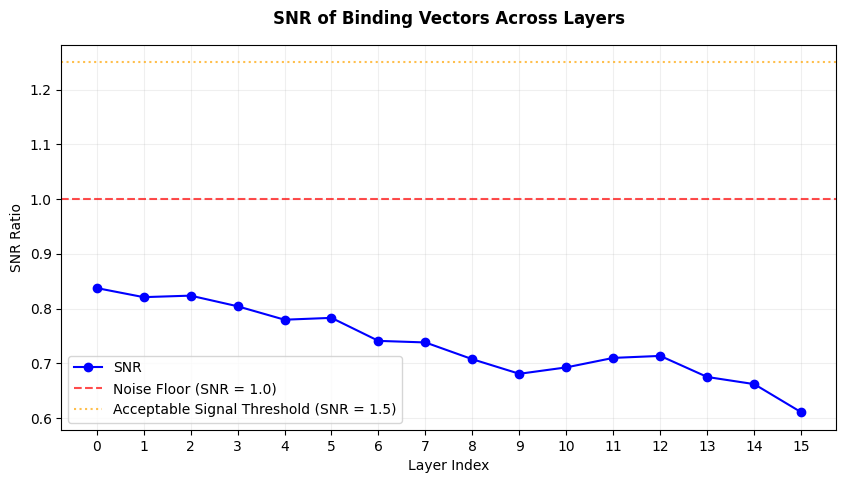

In [ ]:
snrs = plot_signal_to_noise_ratio(bind_vectors, act_full_rules, act_domainsA, act_domainsB, act_contexts)

According to SNR it's just all noise. However, other checks are required too, since the subtraction terms for the shuffled vectors and true vectors are very different. The shuffled vector has to be larger than the binding one, since they don't really cancel the semantics. The beautifully decreasing ratio curve is probably a nature of a residual stream.

Now, the other checks.

### Cosine similarity consistency

Are my binding vectors looking in the same directions?

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def cosine_consistency(bin_vectors):
    n_samples, n_layers, d_model = bin_vectors.shape
    consistency = []

    for l in range(n_layers):
        layer_vecs = bin_vectors[:, l, :]
        # pairwise cosine similarities
        sim_matrix = cosine_similarity(layer_vecs)
        # take upper triangle only (exclude diagonal)
        upper = sim_matrix[np.triu_indices(n_samples, k=1)]
        consistency.append(np.mean(upper))

    return consistency

In [ ]:
def plot_within_groups_cosine(bin_vectors, rule_labels):
    n_samples, n_layers, d_model = bin_vectors.shape

    # Ensure rule_labels is a numpy array for efficient indexing
    rule_labels = np.array(rule_labels)

    unique_rule_types = np.unique(rule_labels)

    consistency_by_rule = {rule_type: [] for rule_type in unique_rule_types}

    for l in range(n_layers):
        for r_type in unique_rule_types:
            # Get indices for the current rule type
            indices = np.where(rule_labels == r_type)[0]

            if len(indices) >= 2: # Need at least two samples for pairwise similarity
                # Extract vectors for the current rule type and layer
                layer_vecs = bin_vectors[indices, l, :]

                # Calculate pairwise cosine similarities
                sim_matrix = cosine_similarity(layer_vecs)

                # Take upper triangle only (exclude diagonal) and calculate mean
                upper_triangle_indices = np.triu_indices(len(indices), k=1)
                mean_consistency = np.mean(sim_matrix[upper_triangle_indices])
                consistency_by_rule[r_type].append(mean_consistency)
            else:
                # If only one or zero samples, cosine similarity is not well-defined or meaningful for 'consistency'
                consistency_by_rule[r_type].append(np.nan) # Append NaN
    return consistency_by_rule

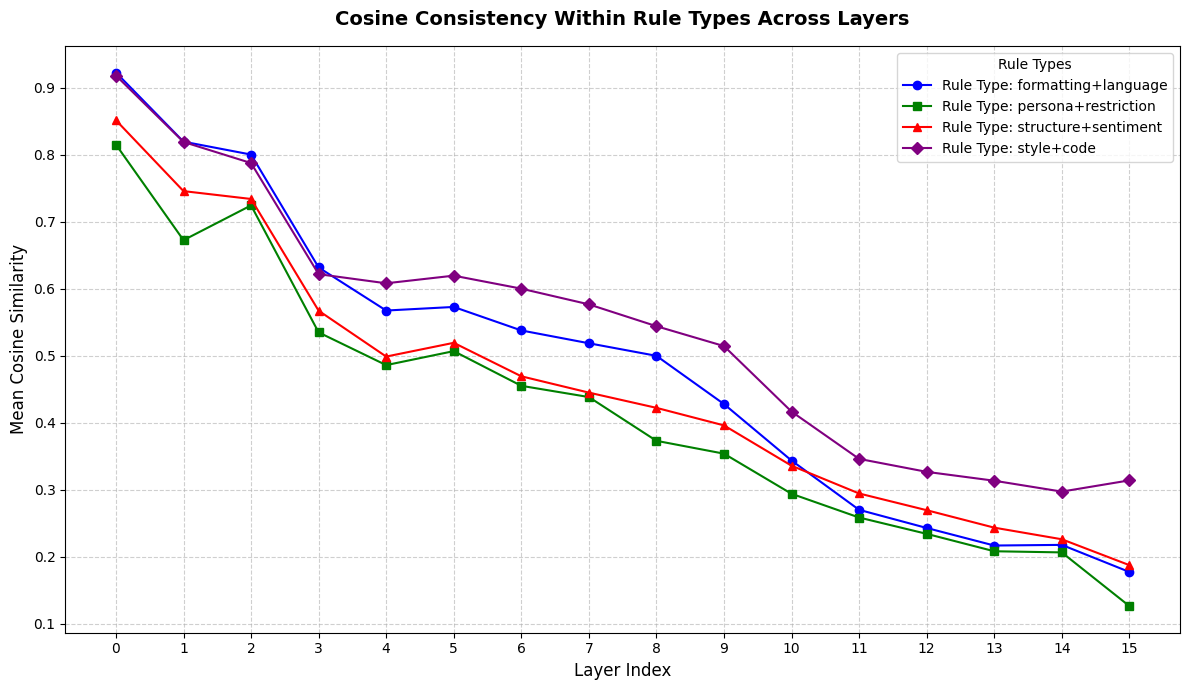

In [ ]:
consistency_results = plot_within_groups_cosine(bind_vectors, rule_types)

plt.figure(figsize=(12, 7))

# Define markers and colors for plotting
markers = ['o', 's', '^', 'D', 'v', 'p', '*'] # Add more if there are more rule types
colors = ['blue', 'green', 'red', 'purple', 'cyan', 'magenta', 'yellow'] # Add more if needed

for i, (rule_type, consistencies) in enumerate(consistency_results.items()):
    # Filter out NaN values for plotting (if any rule type had < 2 samples for a layer)
    valid_consistencies = [c for c in consistencies if not np.isnan(c)]
    valid_layers = [l for l, c in enumerate(consistencies) if not np.isnan(c)]

    if valid_consistencies: # Only plot if there's valid data
        plt.plot(valid_layers, valid_consistencies,
                 marker=markers[i % len(markers)],
                 color=colors[i % len(colors)],
                 label=f'Rule Type: {rule_type}',
                 linewidth=1.5)

plt.title('Cosine Consistency Within Rule Types Across Layers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Layer Index', fontsize=12)
plt.ylabel('Mean Cosine Similarity', fontsize=12)
plt.xticks(range(n_layers)) # Assuming n_layers is defined and correct
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Rule Types')
plt.tight_layout()
plt.show()

In [ ]:
def plot_single_array(array, title, xlabel, ylabel, marker='o', colour='blue', lwidth=1.5):
  """Plots a single array. Useful helper function"""
  plt.figure(figsize=(10, 5))
  plt.plot(range(len(array)), array, marker=marker, color=colour, linewidth=lwidth)
  plt.title(title, fontsize=12, fontweight='bold', pad=15)
  plt.xlabel(xlabel, fontsize=10)
  plt.ylabel(ylabel, fontsize=10)

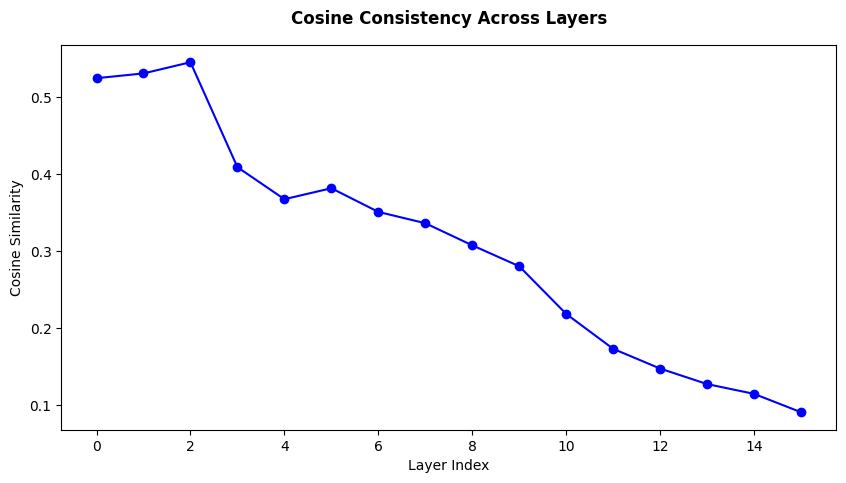

In [ ]:
cosine_cons = cosine_consistency(bind_vectors)
plot_single_array(cosine_cons, "Cosine Consistency Across Layers", "Layer Index", "Cosine Similarity")

### Variance explained by the  first PCA

In [ ]:
def pc1_variance(bin_vectors):
    n_samples, n_layers, d_model = bin_vectors.shape
    variance_explained = []

    for l in range(n_layers):
        layer_vecs = bin_vectors[:, l, :]
        pca = PCA(n_components=1)
        pca.fit(layer_vecs)
        variance_explained.append(pca.explained_variance_ratio_[0])

    return variance_explained

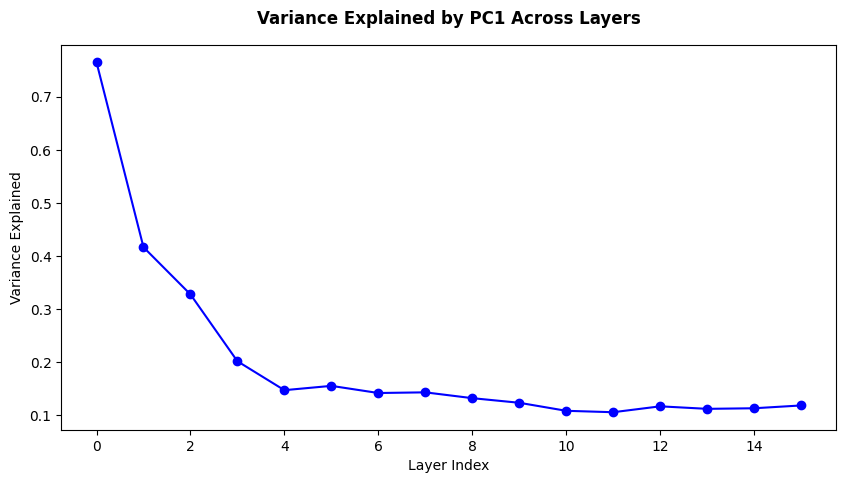

In [ ]:
variance_explained_pc1 = pc1_variance(bind_vectors)
plot_single_array(variance_explained_pc1, "Variance Explained by PC1 Across Layers", "Layer Index", "Variance Explained")

### Phase randomisation

In [ ]:
def phase_randomise(vectors):
    # FFT, randomise phases, inverse FFT
    # preserves power spectrum but destroys structure
    fft = np.fft.rfft(vectors, axis=-1)
    random_phases = np.exp(2j * np.pi * np.random.rand(*fft.shape))
    fft_randomised = np.abs(fft) * random_phases
    return np.fft.irfft(fft_randomised, n=vectors.shape[-1], axis=-1)

def snr_vs_phase_null(bin_vectors):
    n_samples, n_layers, d_model = bin_vectors.shape
    snr_timeline = []

    for l in range(n_layers):
        layer_vecs = bin_vectors[:, l, :]
        null_vecs = phase_randomise(layer_vecs)

        # compare PC1 variance explained
        real_var = PCA(n_components=1).fit(layer_vecs).explained_variance_ratio_[0]
        null_var = PCA(n_components=1).fit(null_vecs).explained_variance_ratio_[0]

        snr_timeline.append(real_var / null_var)

    return snr_timeline

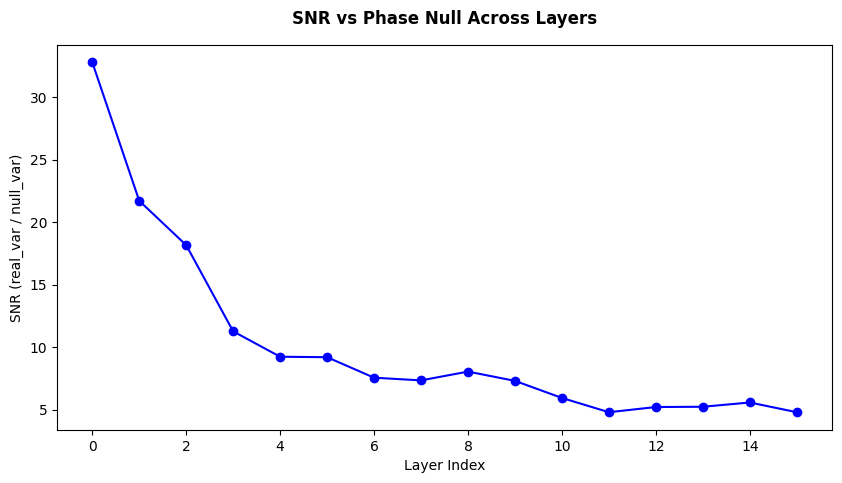

In [ ]:
snr_phase_null = snr_vs_phase_null(bind_vectors)
plot_single_array(snr_phase_null, "SNR vs Phase Null Across Layers", "Layer Index", "SNR (real_var / null_var)")